# EDA INICIAL

### Análises Univariadas:
- Distribuição de acidentes
- Distribuição de causas em acidentes fatais x não-fatais
- Distribuição por Unidade Federativa
- Distribuição de climas em acidentes fatais x não-fatais
- Distribuição das rodovias

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../dados/dados_tratados/prf_tratado.csv')
df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,feriado,acidente_fatal
0,331730.0,2021-01-01,sexta-feira,05:30:00,SP,116,453,REGISTRO,Reação tardia ou ineficiente do condutor,Tombamento,...,1,0,0,0,1,1,-24.561681,-47.867522,True,0
1,331804.0,2021-01-01,sexta-feira,08:05:00,AM,174,937,MANAUS,Reação tardia ou ineficiente do condutor,Colisão traseira,...,1,0,5,1,1,5,-2.508068,-60.036434,True,0
2,331815.0,2021-01-01,sexta-feira,10:10:00,CE,222,"128,5",ITAPAJE,Velocidade Incompatível,Tombamento,...,2,0,0,11,2,12,-3.707626,-39.623509,True,0
3,331823.0,2021-01-01,sexta-feira,12:30:00,RJ,493,18,MAGE,Ingestão de álcool e/ou substâncias psicoativa...,Colisão lateral,...,1,0,1,1,1,3,-22.668712,-43.018627,True,0
4,331843.0,2021-01-01,sexta-feira,14:40:00,RJ,393,252,BARRA DO PIRAI,Condutor Dormindo,Colisão frontal,...,1,1,1,1,2,3,-22.434220,-43.775615,True,0


In [3]:
sns.set_theme(style='whitegrid')

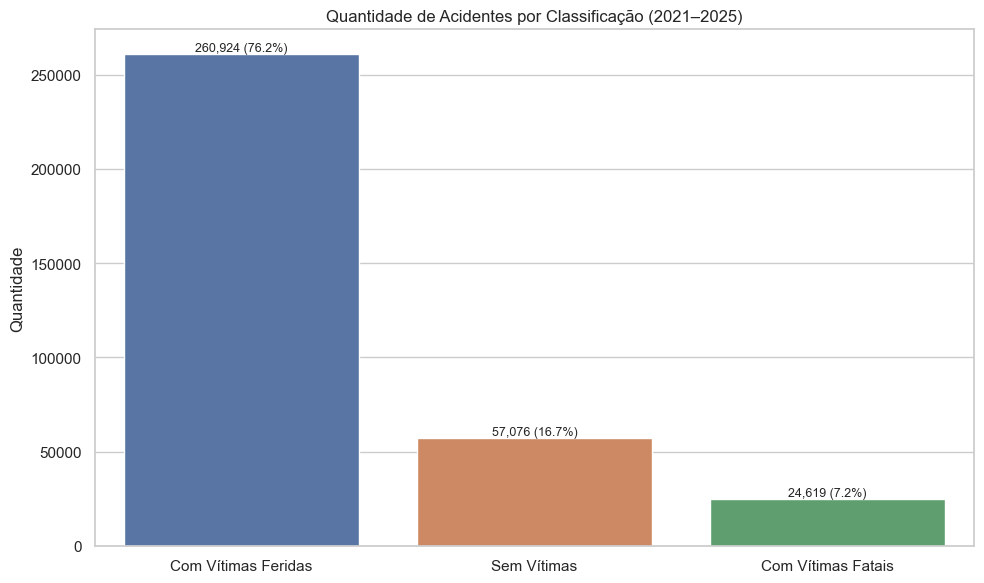

In [4]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df,
    x='classificacao_acidente',
    order=df['classificacao_acidente'].value_counts().index
)

total = len(df)
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height):,} ({height/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=9
        )

plt.title('Quantidade de Acidentes por Classificação (2021–2025)')
plt.xlabel('')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()


In [ ]:
df_fatal = df[df['classificacao_acidente'] == 'Com Vítimas Fatais']
#Criaremos um sub-dataset para acidentes fatais

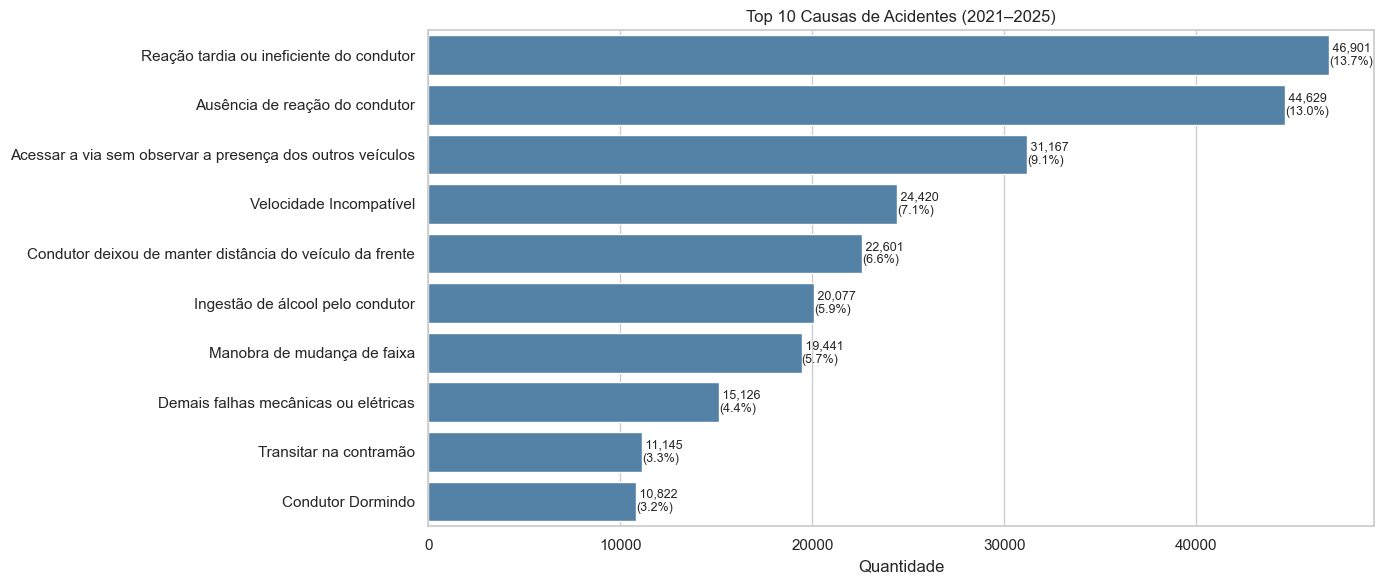

In [6]:
top10_causas = df['causa_acidente'].value_counts().head(10).index

plt.figure(figsize=(14, 6))
ax = sns.countplot(
    data=df[df['causa_acidente'].isin(top10_causas)],
    y='causa_acidente',
    order=top10_causas,
    color='steelblue'
)

total = len(df)
for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f' {int(width):,}\n({width/total*100:.1f}%)',
            ha='left', va='center', fontsize=9
        )

plt.title('Top 10 Causas de Acidentes (2021–2025)')
plt.xlabel('Quantidade')
plt.ylabel('')
plt.tight_layout()
plt.show()

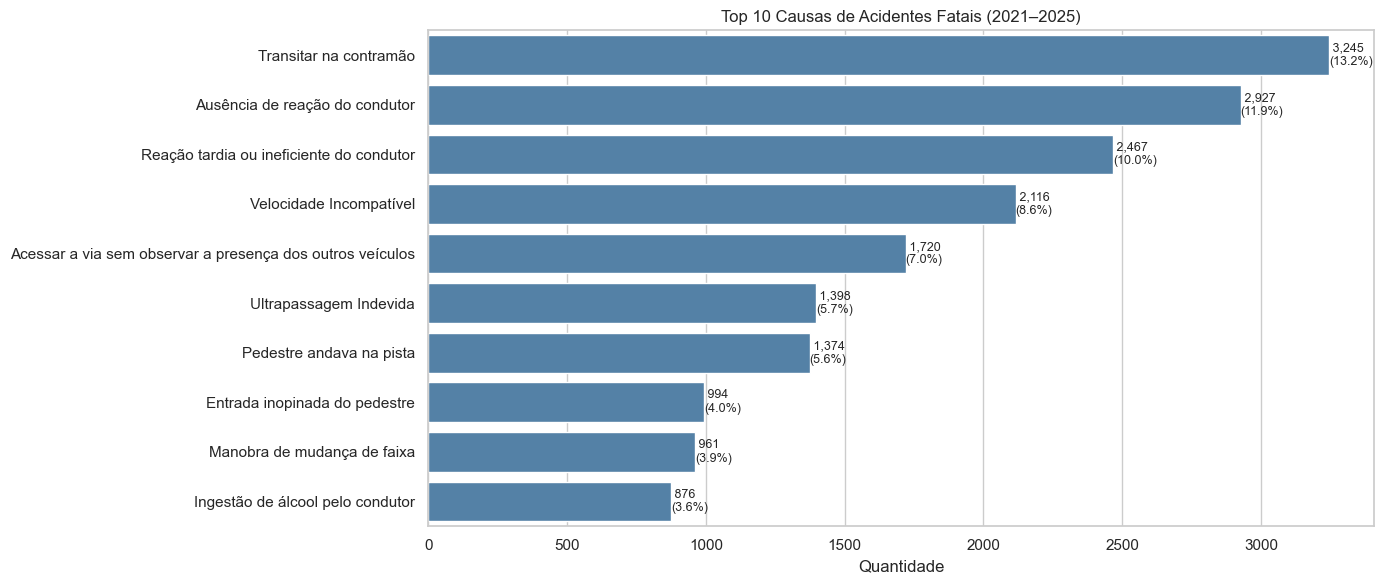

In [7]:
top10_causas_letais = df_fatal['causa_acidente'].value_counts().head(10).index
plt.figure(figsize=(14, 6))
ax = sns.countplot(
    data=df_fatal[df_fatal['causa_acidente'].isin(top10_causas_letais)],
    y='causa_acidente',
    order=top10_causas_letais,
    color='steelblue'
)

total = len(df_fatal)
for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f' {int(width):,}\n({width/total*100:.1f}%)',
            ha='left', va='center', fontsize=9
        )

plt.title('Top 10 Causas de Acidentes Fatais (2021–2025)')
plt.xlabel('Quantidade')
plt.ylabel('')
plt.tight_layout()
plt.show()

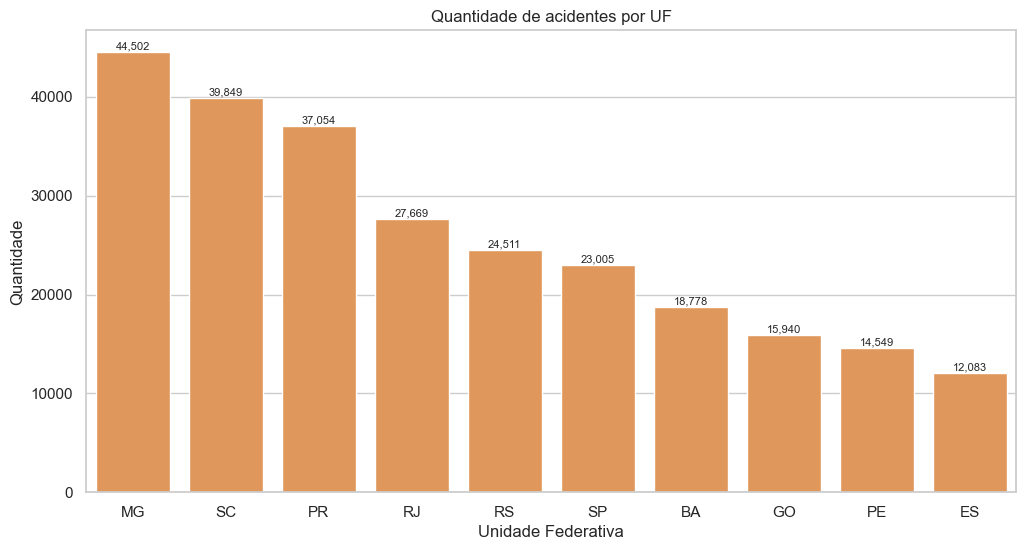

In [8]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df[df['uf'].isin(df['uf'].value_counts().head(10).index)],
    x = 'uf', 
    order=df['uf'].value_counts().head(10).index,
    color="#f59546")

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height+80,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=8
        )

plt.xlabel('Unidade Federativa')
plt.ylabel('Quantidade')
plt.title('Quantidade de acidentes por UF')
plt.show()

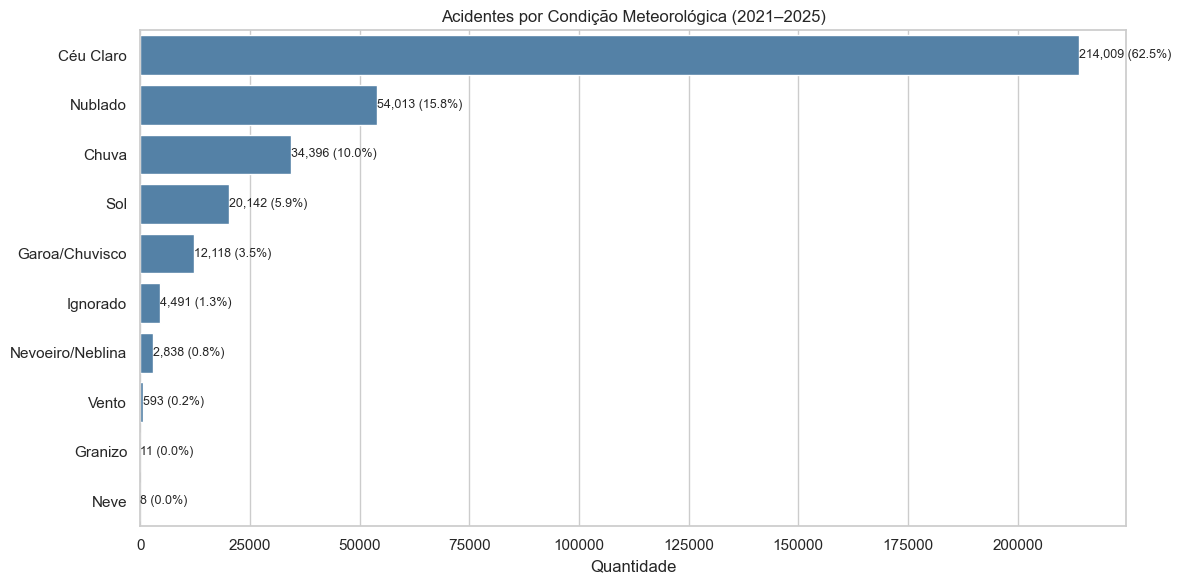

In [9]:
top_clima = df['condicao_metereologica'].value_counts().index

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df,
    y='condicao_metereologica',
    order=top_clima,
    color='steelblue'
)

total = len(df)
for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f'{int(width):,} ({width/total*100:.1f}%)',
            ha='left', va='center', fontsize=9
        )

plt.title('Acidentes por Condição Meteorológica (2021–2025)')
plt.xlabel('Quantidade')
plt.ylabel('')
plt.tight_layout()
plt.show()

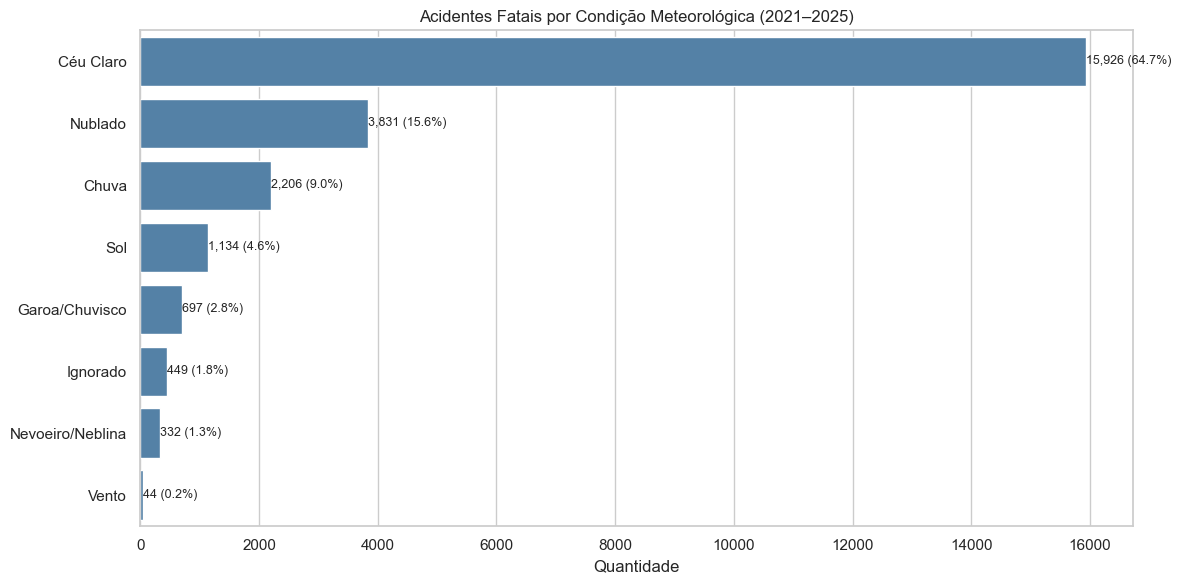

In [10]:
top_clima = df_fatal['condicao_metereologica'].value_counts().index

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_fatal,
    y='condicao_metereologica',
    order=top_clima,
    color='steelblue'
)

total = len(df_fatal)
for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f'{int(width):,} ({width/total*100:.1f}%)',
            ha='left', va='center', fontsize=9
        )

plt.title('Acidentes Fatais por Condição Meteorológica (2021–2025)')
plt.xlabel('Quantidade')
plt.ylabel('')
plt.tight_layout()
plt.show()

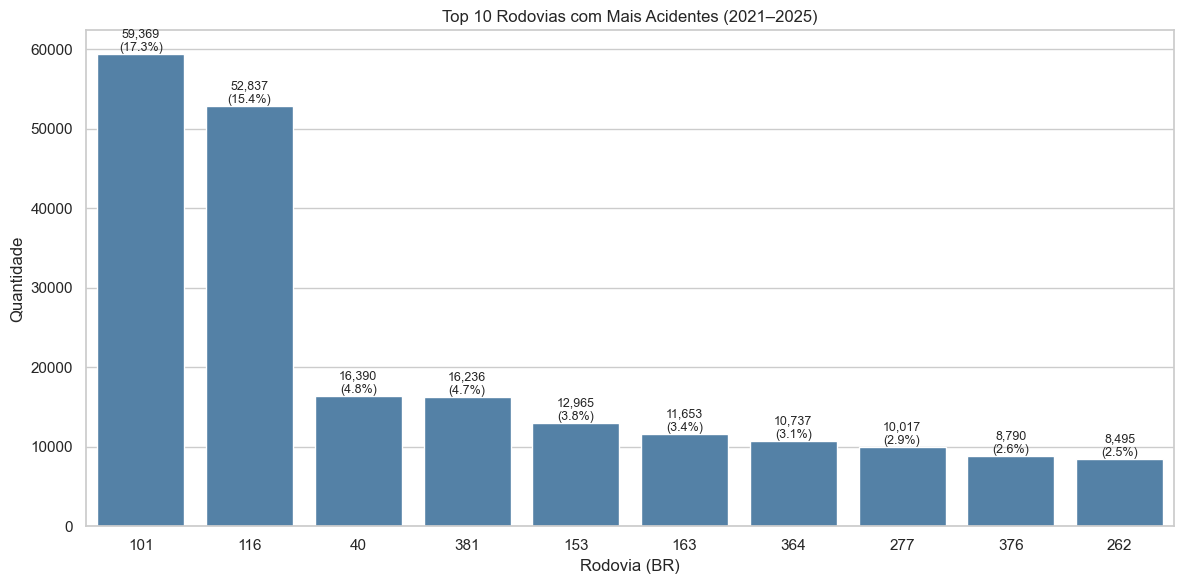

In [11]:
top10_br = df['br'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df[df['br'].isin(top10_br)],
    x='br',
    order=top10_br,
    color='steelblue'
)

total = len(df)
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{int(height):,}\n({height/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=9
        )

plt.title('Top 10 Rodovias com Mais Acidentes (2021–2025)')
plt.xlabel('Rodovia (BR)')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

### O fato das rodovias 101 e 116 serem as maiores rodovias brasileiras tem relação com a quantidade de acidentes?

In [12]:
#Lista de extensão de cada rodovia citada no gráfico acima
extensao_br = {
    101: 4824,
    116: 4713,
    40:  1178,
    381: 1185,
    153: 3542,
    163: 3579,
    364: 4309,
    277: 732,
    376: 1000,
    262: 2213
}

acidentes_por_br = df[df['br'].isin(extensao_br.keys())].groupby('br').size().reset_index(name='acidentes')
acidentes_por_br['extensao_km'] = acidentes_por_br['br'].map(extensao_br)
acidentes_por_br['acidentes_por_km'] = acidentes_por_br['acidentes'] / acidentes_por_br['extensao_km']
acidentes_por_br.sort_values('extensao_km', ascending=False)

,br,acidentes,extensao_km,acidentes_por_km
1,101,59369,4824,12.307007
2,116,52837,4713,11.210906
7,364,10737,4309,2.491761
4,163,11653,3579,3.255937
3,153,12965,3542,3.660361
5,262,8495,2213,3.838681
9,381,16236,1185,13.701266
0,40,16390,1178,13.913413
8,376,8790,1000,8.790000
6,277,10017,732,13.684426


Podemos inferir que não, o tamanho da rodovia não é o único fator na quantidade de acidentes. <br>
Já que, comparada à BR-101, a BR-277 (6x menor), possui taxa maior de acidentes por KM <br> 
Além da BR-364 (tamanho próximo da BR-101, apenas 515KM a menos) que possui taxa quase 6x menor de acidentes por KM

No próximo notebook, iremos fazer testes de correlação para confirmar essa hipótese.

# EDA Aprofundada

### Análises Bivariadas

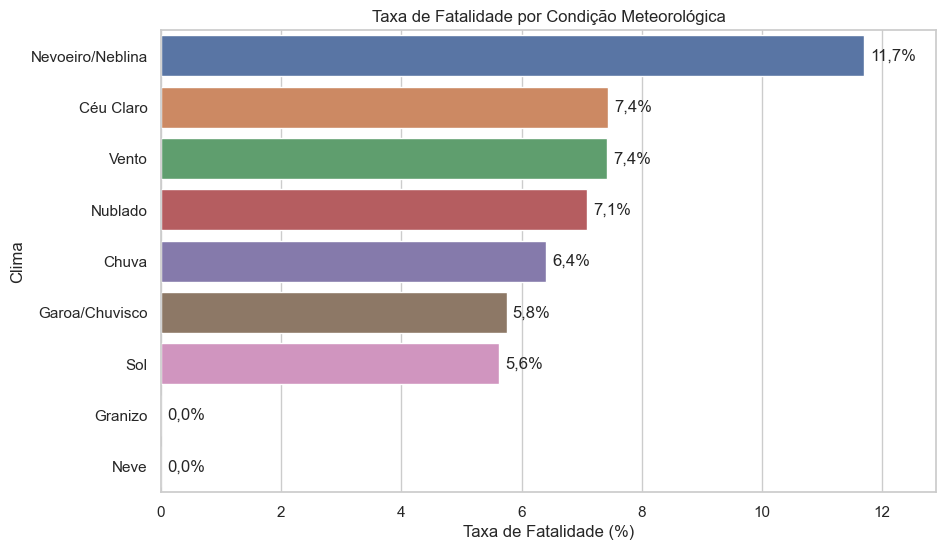

In [87]:
df_biv_clima = df[df['condicao_metereologica'] != 'Ignorado'].groupby('condicao_metereologica')['acidente_fatal'].mean()*100
df_biv_clima = df_biv_clima.sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_biv_clima, x='acidente_fatal', y='condicao_metereologica')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%'.replace('.',','), va='center')
ax.set_xlim(0, df_biv_clima['acidente_fatal'].max() + 1.2)
plt.xlabel('Taxa de Fatalidade (%)')
plt.ylabel('Clima')
plt.title('Taxa de Fatalidade por Condição Meteorológica')
plt.show()

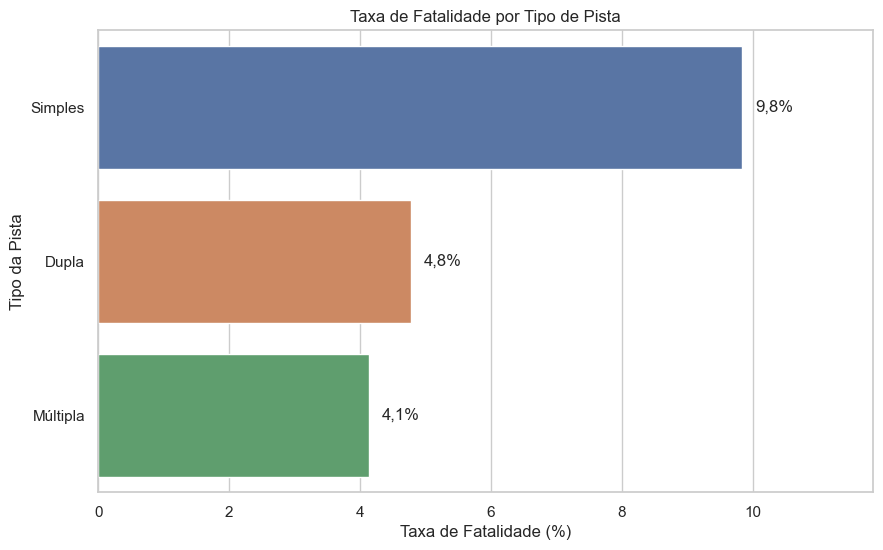

In [99]:
df_biv_pista = df.groupby('tipo_pista')['acidente_fatal'].mean()*100
df_biv_pista = df_biv_pista.sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_biv_pista, x='acidente_fatal', y='tipo_pista')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%'.replace('.',','), va='center')
ax.set_xlim(0, df_biv_pista['acidente_fatal'].max() + 2)
plt.xlabel('Taxa de Fatalidade (%)')
plt.ylabel('Tipo da Pista')
plt.title('Taxa de Fatalidade por Tipo de Pista')
plt.show()